In [1]:
# ============================================================
# CELL 1: Install & Imports
# ============================================================
!pip install -q evaluate bert_score rouge_score sacrebleu
import nltk
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evaluate

rouge    = evaluate.load('rouge')
bleu     = evaluate.load('sacrebleu') 
meteor   = evaluate.load('meteor')
bertscore = evaluate.load('bertscore')

print("✅ Semua pustaka siap")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cud

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


✅ Semua pustaka siap


In [2]:
import glob, shutil, subprocess, time

In [3]:
# ============================================================
# CELL 2: Fix Path Gambar (cukup satu file, konten sama)
# ============================================================
# Gunakan salah satu — semua isinya identik
JALUR_TEST_ASLI = "/kaggle/input/datasets/allyciajoanmicheline/qwen35/results/LLaMA-Factory/data/qwen35_test.json"
GAMBAR_BARU     = "/kaggle/input/datasets/allyciajoanmicheline/dataset/dataset/cropped_images"
JALUR_TEST_FIXED = "/kaggle/working/qwen35_test_fixed.json"

# Verifikasi
print("Folder gambar ada:", os.path.exists(GAMBAR_BARU))

with open(JALUR_TEST_ASLI) as f:
    data_test = json.load(f)
print(f"Jumlah sampel test: {len(data_test)}")

# Fix path
data_fixed = []
for item in data_test:
    item_baru = item.copy()
    if "images" in item_baru:
        item_baru["images"] = [
            os.path.join(GAMBAR_BARU, os.path.basename(p))
            for p in item_baru["images"]
        ]
    data_fixed.append(item_baru)

# Verifikasi sample pertama
print("\nPath setelah fix:", data_fixed[0]["images"][0])
print("File ada:", os.path.exists(data_fixed[0]["images"][0]))

# Simpan
with open(JALUR_TEST_FIXED, "w", encoding="utf-8") as f:
    json.dump(data_fixed, f, ensure_ascii=False, indent=2)
print(f"\n✅ Tersimpan: {JALUR_TEST_FIXED}")

Folder gambar ada: True
Jumlah sampel test: 600

Path setelah fix: /kaggle/input/datasets/allyciajoanmicheline/dataset/dataset/cropped_images/crop_2109_F_29700_jpeg.rf.0ecbf45edc76a2f6f5fbcb528651b568.jpg
File ada: True

✅ Tersimpan: /kaggle/working/qwen35_test_fixed.json


In [4]:
%cd /kaggle/working
!rm -rf LLaMA-Factory
!git clone https://github.com/hiyouga/LLaMA-Factory.git
%cd /kaggle/working/LLaMA-Factory
!pip install -q -e .
!pip install -q rouge-chinese jieba qwen-vl-utils bitsandbytes

print("✅ LLaMA-Factory siap")

/kaggle/working
Cloning into 'LLaMA-Factory'...
remote: Enumerating objects: 27464, done.
remote: Counting objects: 100% (219/219), done.
remote: Compressing objects: 100% (176/176), done.
remote: Total 27464 (delta 137), reused 43 (delta 43), pack-reused 27245 (from 3)
Receiving objects: 100% (27464/27464), 13.32 MiB | 24.45 MiB/s, done.
Resolving deltas: 100% (19656/19656), done.
/kaggle/working/LLaMA-Factory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [5]:
# ============================================================
# CELL 4: Daftarkan Dataset Test
# ============================================================
DATA_DIR     = "/kaggle/working/LLaMA-Factory/data"
DATASET_INFO = f"{DATA_DIR}/dataset_info.json"

# Copy fixed JSON ke data dir
shutil.copy(JALUR_TEST_FIXED, f"{DATA_DIR}/qwen35_test_fixed.json")

# Daftarkan
with open(DATASET_INFO) as f:
    info = json.load(f)

info["adas_test"] = {
    "file_name":  "qwen35_test_fixed.json",
    "formatting": "sharegpt",
    "columns": {
        "messages": "conversations",
        "images":   "images"
    }
}

with open(DATASET_INFO, "w") as f:
    json.dump(info, f, indent=2)

print("✅ Dataset terdaftar")
print(json.dumps(info["adas_test"], indent=2))

✅ Dataset terdaftar
{
  "file_name": "qwen35_test_fixed.json",
  "formatting": "sharegpt",
  "columns": {
    "messages": "conversations",
    "images": "images"
  }
}


In [6]:
# ============================================================
# CELL 5: Login HuggingFace
# ============================================================
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
login(token=UserSecretsClient().get_secret("HF_TOKEN"))
print("✅ Login HF berhasil")

✅ Login HF berhasil


In [7]:
# ============================================================
# CELL 6: Konfigurasi Ketiga Model
# ============================================================
KONFIGURASI_MODEL = {
    "PaliGemma2-3B": {
        "model_name_or_path":   "google/paligemma2-3b-pt-224",
        "adapter_name_or_path": "/kaggle/input/datasets/allyciajoanmicheline/paligemma/paligemma2_3b_lora/checkpoint-1325",
        "template":             "paligemma",
        "output_dir":           "/kaggle/working/hasil_test_paligemma",
    },
    "Qwen3.5-4B": {
        "model_name_or_path":   "Qwen/Qwen3.5-4B",
        "adapter_name_or_path": "/kaggle/input/datasets/allyciajoanmicheline/qwen35/results/qwen35_4b_lora/checkpoint-1325",
        "template":             "qwen3_5",
        "output_dir":           "/kaggle/working/hasil_test_qwen",
    },
    "InternVL3_5-4B": {
        "model_name_or_path":   "OpenGVLab/InternVL3_5-4B-HF",
        "adapter_name_or_path": "/kaggle/input/datasets/allyciajoanmicheline/internvl35/internvl35_4b_lora/checkpoint-1325",
        "template":             "intern_vl",
        "output_dir":           "/kaggle/working/hasil_test_internvl",
    },
}

# Verifikasi adapter ada semua
for nama, cfg in KONFIGURASI_MODEL.items():
    ada = os.path.exists(cfg["adapter_name_or_path"])
    print(f"{'✅' if ada else '❌'} {nama}: {cfg['adapter_name_or_path']}")

✅ PaliGemma2-3B: /kaggle/input/datasets/allyciajoanmicheline/paligemma/paligemma2_3b_lora/checkpoint-1325
✅ Qwen3.5-4B: /kaggle/input/datasets/allyciajoanmicheline/qwen35/results/qwen35_4b_lora/checkpoint-1325
✅ InternVL3_5-4B: /kaggle/input/datasets/allyciajoanmicheline/internvl35/internvl35_4b_lora/checkpoint-1325


In [8]:
# ============================================================
# CELL 7: Fungsi Inferensi
# ============================================================
def jalankan_inferensi(nama_model, cfg):
    print(f"\n{'='*60}")
    print(f"🚀 Inferensi: {nama_model}")
    print(f"{'='*60}")

    os.makedirs(cfg["output_dir"], exist_ok=True)

    # Skip kalau sudah ada outputnya
    jalur_pred = os.path.join(cfg["output_dir"], "generated_predictions.jsonl")
    if os.path.exists(jalur_pred):
        print(f"⏭️  Output sudah ada, skip inferensi ulang")
        return True

    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"]    = "0"   
    env["NCCL_DEBUG"]              = "OFF"
    env["TOKENIZERS_PARALLELISM"]  = "false"

    cmd = [
        "llamafactory-cli", "train",
        "--stage",                      "sft",
        "--model_name_or_path",         cfg["model_name_or_path"],
        "--adapter_name_or_path",       cfg["adapter_name_or_path"],
        "--trust_remote_code",          "True",
        "--eval_dataset",               "adas_test",
        "--dataset_dir",                "data",
        "--template",                   cfg["template"],
        "--finetuning_type",            "lora",
        "--quantization_bit",           "4",
        "--bf16",                       "True",
        "--do_train",                   "False",
        "--do_predict",                 "True",
        "--predict_with_generate",      "True",
        "--per_device_eval_batch_size", "1",
        "--dataloader_num_workers",     "0",     
        "--report_to",                  "none",
        "--output_dir",                 cfg["output_dir"],
    ]

    mulai = time.time()
    
    # Menggunakan Popen untuk mencegah layar membeku (freeze)
    proses = subprocess.Popen(
        cmd, 
        env=env, 
        cwd="/kaggle/working/LLaMA-Factory",
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    
    # Mencetak log terminal langsung ke layar
    for baris in proses.stdout:
        print(baris, end="")
        
    proses.wait()
    durasi = time.time() - mulai

    if proses.returncode == 0:
        print(f"✅ {nama_model} selesai dalam {durasi/60:.1f} menit")
        return True
    else:
        print(f"❌ {nama_model} gagal (exit code {proses.returncode})")
        return False

In [9]:
# ============================================================
# CELL 8: Jalankan Inferensi — PaliGemma2-3B
# ============================================================
jalankan_inferensi("PaliGemma2-3B", KONFIGURASI_MODEL["PaliGemma2-3B"])


🚀 Inferensi: PaliGemma2-3B
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
[WARNING|2026-06-09 11:44:42] llamafactory.hparams.parser:149 >> Evaluating model in 4/8-bit mode may cause lower scores.
[INFO|2026-06-09 11:44:42] llamafactory.hparams.parser:523 >> Process rank: 0, world size: 1, device: cuda:0, distributed training: False, compute dtype: torch.bfloat16
[INFO|configuration_utils.py:667] 2026-06-09 11:44:42,370 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--google--paligemma2-3b-pt

True

In [10]:
# ============================================================
# CELL 10: Jalankan Inferensi — InternVL3_5-4B
# ============================================================
jalankan_inferensi("InternVL3_5-4B", KONFIGURASI_MODEL["InternVL3_5-4B"])


🚀 Inferensi: InternVL3_5-4B
[WARNING|2026-06-09 12:07:50] llamafactory.hparams.parser:149 >> Evaluating model in 4/8-bit mode may cause lower scores.
[INFO|2026-06-09 12:07:50] llamafactory.hparams.parser:523 >> Process rank: 0, world size: 1, device: cuda:0, distributed training: False, compute dtype: torch.bfloat16
[INFO|configuration_utils.py:667] 2026-06-09 12:07:50,256 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--OpenGVLab--InternVL3_5-4B-HF/snapshots/6bd4487402110ef9889ba50eb7aefeb302526fed/config.json
[INFO|configuration_utils.py:739] 2026-06-09 12:07:50,268 >> Model config InternVLConfig {
  "architectures": [
    "InternVLForConditionalGeneration"
  ],
  "downsample_ratio": 0.5,
  "dtype": "bfloat16",
  "image_seq_length": 256,
  "image_token_id": 151671,
  "model_type": "internvl",
  "projector_hidden_act": "gelu",
  "text_config": {
    "_name_or_path": "/root/codespace/checkpoints/Qwen3-4B",
    "architectures": [
      "Qwen

True

In [11]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llamafactory 0.9.6.dev0 requires transformers!=4.52.0,!=4.57.0,<=5.6.0,>=4.55.0, but you have transformers 5.10.0.dev0 which is incompatible.


In [12]:
# ============================================================
# CELL 7: Fungsi Inferensi (BYPASS VERSION CHECK)
# ============================================================
def jalankan_inferensi(nama_model, cfg):
    print(f"\n{'='*60}")
    print(f"🚀 Inferensi: {nama_model}")
    print(f"{'='*60}")

    os.makedirs(cfg["output_dir"], exist_ok=True)

    # Skip kalau sudah ada outputnya
    jalur_pred = os.path.join(cfg["output_dir"], "generated_predictions.jsonl")
    if os.path.exists(jalur_pred):
        print(f"⏭️  Output sudah ada, skip inferensi ulang")
        return True

    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"]    = "0"   
    env["NCCL_DEBUG"]              = "OFF"
    env["TOKENIZERS_PARALLELISM"]  = "false"
    
    # SUNTIKKAN PERINTAH BYPASS DI SINI
    env["DISABLE_VERSION_CHECK"]   = "1"   

    cmd = [
        "llamafactory-cli", "train",
        "--stage",                      "sft",
        "--model_name_or_path",         cfg["model_name_or_path"],
        "--adapter_name_or_path",       cfg["adapter_name_or_path"],
        "--trust_remote_code",          "True",
        "--eval_dataset",               "adas_test",
        "--dataset_dir",                "data",
        "--template",                   cfg["template"],
        "--finetuning_type",            "lora",
        "--quantization_bit",           "4",
        "--bf16",                       "True",
        "--do_train",                   "False",
        "--do_predict",                 "True",
        "--predict_with_generate",      "True",
        "--per_device_eval_batch_size", "1",
        "--dataloader_num_workers",     "0",     
        "--report_to",                  "none",
        "--output_dir",                 cfg["output_dir"],
    ]

    mulai = time.time()
    
    # Menggunakan Popen untuk mencegah layar membeku (freeze)
    proses = subprocess.Popen(
        cmd, 
        env=env, 
        cwd="/kaggle/working/LLaMA-Factory",
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    
    # Mencetak log terminal langsung ke layar
    for baris in proses.stdout:
        print(baris, end="")
        
    proses.wait()
    durasi = time.time() - mulai

    if proses.returncode == 0:
        print(f"✅ {nama_model} selesai dalam {durasi/60:.1f} megit")
        return True
    else:
        print(f"❌ {nama_model} gagal (exit code {proses.returncode})")
        return False

In [13]:
# ============================================================
# CELL 9: Jalankan Inferensi — Qwen3.5-4B
# ============================================================
jalankan_inferensi("Qwen3.5-4B", KONFIGURASI_MODEL["Qwen3.5-4B"])


🚀 Inferensi: Qwen3.5-4B
[WARNING|2026-06-09 12:51:57] llamafactory.extras.misc:155 >> Version checking has been disabled, may lead to unexpected behaviors.
[WARNING|2026-06-09 12:52:01] llamafactory.hparams.parser:149 >> Evaluating model in 4/8-bit mode may cause lower scores.
[INFO|2026-06-09 12:52:01] llamafactory.hparams.parser:523 >> Process rank: 0, world size: 1, device: cuda:0, distributed training: False, compute dtype: torch.bfloat16
[INFO|configuration_utils.py:783] 2026-06-09 12:52:01,631 >> loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--Qwen--Qwen3.5-4B/snapshots/851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a/config.json
[INFO|configuration_utils.py:859] 2026-06-09 12:52:01,648 >> Model config Qwen3_5Config {
  "architectures": [
    "Qwen3_5ForConditionalGeneration"
  ],
  "image_token_id": 248056,
  "model_type": "qwen3_5",
  "text_config": {
    "attention_bias": false,
    "attention_dropout": 0.0,
    "attn_output_gate": true,
    

True

In [14]:
# ============================================================
# CELL 11: Cek Semua Output
# ============================================================
print("📋 Status output inferensi:")
for nama, cfg in KONFIGURASI_MODEL.items():
    pred  = os.path.join(cfg["output_dir"], "generated_predictions.jsonl")
    hasil = os.path.join(cfg["output_dir"], "predict_results.json")
    print(f"\n  {nama}:")
    print(f"    predictions : {'✅' if os.path.exists(pred)  else '❌'} {pred}")
    print(f"    results     : {'✅' if os.path.exists(hasil) else '❌'} {hasil}")
    if os.path.exists(pred):
        with open(pred) as f:
            baris = [json.loads(l) for l in f]
        print(f"    jumlah pred : {len(baris)}")
        print(f"    contoh pred : {baris[0].get('predict','')[:80]}...")

📋 Status output inferensi:

  PaliGemma2-3B:
    predictions : ✅ /kaggle/working/hasil_test_paligemma/generated_predictions.jsonl
    results     : ✅ /kaggle/working/hasil_test_paligemma/predict_results.json
    jumlah pred : 600
    contoh pred : Terdeteksi retak memanjang dengan tingkat keparahan ringan....

  Qwen3.5-4B:
    predictions : ✅ /kaggle/working/hasil_test_qwen/generated_predictions.jsonl
    results     : ✅ /kaggle/working/hasil_test_qwen/predict_results.json
    jumlah pred : 600
    contoh pred : <think>

</think>

Terdeteksi retak memanjang dengan tingkat keparahan ringan....

  InternVL3_5-4B:
    predictions : ✅ /kaggle/working/hasil_test_internvl/generated_predictions.jsonl
    results     : ✅ /kaggle/working/hasil_test_internvl/predict_results.json
    jumlah pred : 600
    contoh pred : Terdeteksi retak memanjang dengan tingkat keparahan ringan....


In [15]:
# ============================================================
# CELL 12: Hitung Semua Metrik
# ============================================================
!pip install -q transformers==4.46.3 evaluate bert_score rouge_score sacrebleu

import json
import os

# Menyimpan konfigurasi model ke berkas agar dapat dibaca oleh ruang terisolasi
with open("/kaggle/working/konfig_eval.json", "w", encoding="utf-8") as f:
    json.dump(KONFIGURASI_MODEL, f)

# Merakit skrip Python murni untuk dieksekusi di luar memori utama
kode_evaluasi = """
import os, json, re
import numpy as np
import pandas as pd
import evaluate as ev

rouge_metric     = ev.load('rouge')
bleu_metric      = ev.load('sacrebleu')
meteor_metric    = ev.load('meteor')
bertscore_metric = ev.load('bertscore')

def bersihkan_teks(teks):
    teks_bersih = re.sub(r'<think>.*?</think>', '', teks, flags=re.DOTALL)
    return teks_bersih.strip()

def muat_prediksi(jalur):
    prediksi, referensi = [], []
    with open(jalur, encoding='utf-8') as f:
        for baris in f:
            d = json.loads(baris)
            prediksi.append(bersihkan_teks(d.get("predict", "")))
            referensi.append(bersihkan_teks(d.get("label", "")))
    return prediksi, referensi

def hitung_metrik(prediksi, referensi):
    print("    ROUGE...");   r = rouge_metric.compute(predictions=prediksi, references=referensi, use_stemmer=True)
    print("    BLEU...");    b = bleu_metric.compute(predictions=prediksi, references=[[x] for x in referensi])
    print("    METEOR...");  m = meteor_metric.compute(predictions=prediksi, references=referensi)
    print("    BERTScore..."); bs = bertscore_metric.compute(predictions=prediksi, references=referensi, lang="en", device="cuda")
    return {
        "ROUGE-1":      round(r["rouge1"],                   4),
        "ROUGE-2":      round(r["rouge2"],                   4),
        "ROUGE-L":      round(r["rougeL"],                   4),
        "BLEU":         round(b["score"] / 100,              4),
        "METEOR":       round(m["meteor"],                   4),
        "BERTScore-F1": round(float(np.mean(bs['f1'])),      4),
    }

def muat_waktu(jalur):
    with open(jalur) as f:
        d = json.load(f)
    sps = d.get("predict_samples_per_second", 1)
    return {
        "Detik/Gambar": round(1 / sps, 4),
        "Sampel/Detik": round(sps,     4),
    }

# Membaca kembali konfigurasi dari notebook utama
with open("/kaggle/working/konfig_eval.json", "r", encoding="utf-8") as f:
    KONFIGURASI_MODEL = json.load(f)

baris_tabel = []
for nama, cfg in KONFIGURASI_MODEL.items():
    jalur_pred  = os.path.join(cfg["output_dir"], "generated_predictions.jsonl")
    jalur_waktu = os.path.join(cfg["output_dir"], "predict_results.json")

    if not os.path.exists(jalur_pred) or not os.path.exists(jalur_waktu):
        print(f"Peringatan: Data prediksi untuk {nama} tidak ditemukan, proses dilewati.")
        continue

    print(f"\\nMemproses kalkulasi metrik untuk arsitektur {nama}...")
    pred, ref = muat_prediksi(jalur_pred)
    metrik = hitung_metrik(pred, ref)
    waktu  = muat_waktu(jalur_waktu)
    baris_tabel.append({"Model": nama, **metrik, **waktu})
    print(f"Kalkulasi Sukses: Skor ROUGE-L={metrik['ROUGE-L']} | Skor BERTScore={metrik['BERTScore-F1']}")

df = pd.DataFrame(baris_tabel)
kolom_tampil = ["Model","ROUGE-1","ROUGE-2","ROUGE-L","BLEU","METEOR","BERTScore-F1","Detik/Gambar"]
print("\\n===========================================================================")
print("TABEL KOMPARASI EVALUASI — TEST SET PENGUJIAN ASPAL")
print("===========================================================================")
print(df[kolom_tampil].to_string(index=False))
df.to_csv("/kaggle/working/komparasi_model.csv", index=False)
print("\\nBerkas evaluasi berhasil diamankan pada direktori: komparasi_model.csv")
"""

# Menulis skrip ke dalam sistem penyimpanan Kaggle
with open("/kaggle/working/eksekutor_metrik.py", "w", encoding="utf-8") as f:
    f.write(kode_evaluasi)

# Menjalankan skrip melalui sub-proses terminal agar terisolasi dari memori utama
!python /kaggle/working/eksekutor_metrik.py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 91.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.24.0 requires transformers>=4.56.1, but you have transformers 4.46.3 which is incompatible.
llamafactory 0.9.6.dev0 requires transformers!=4.52.0,!=4.57.0,<=5.6.0,>=4.55.0, but you have transformers 4.46.3 which is incompatible.
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
2026-06-09 13:48:12.83

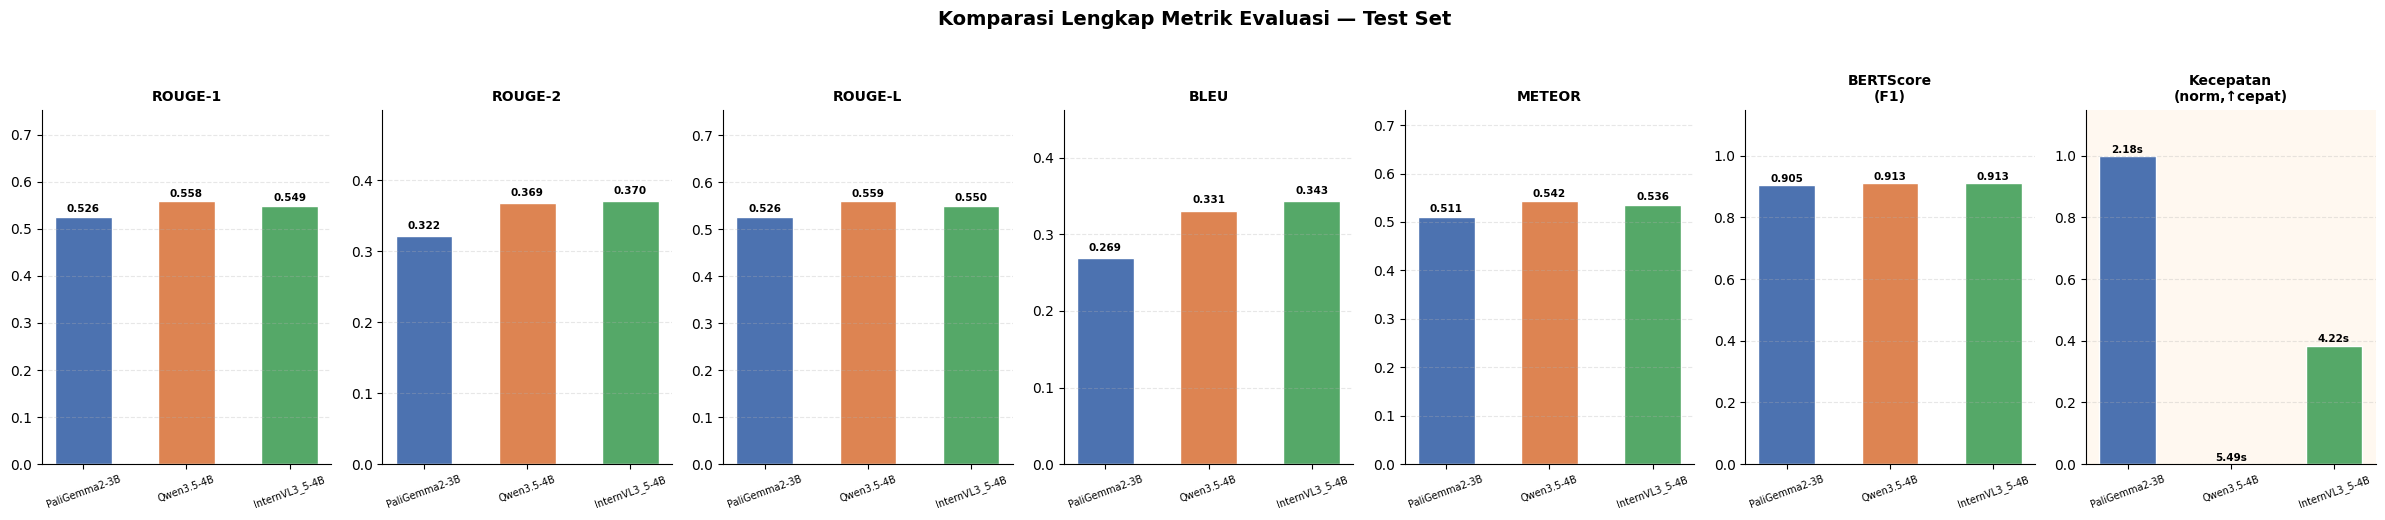

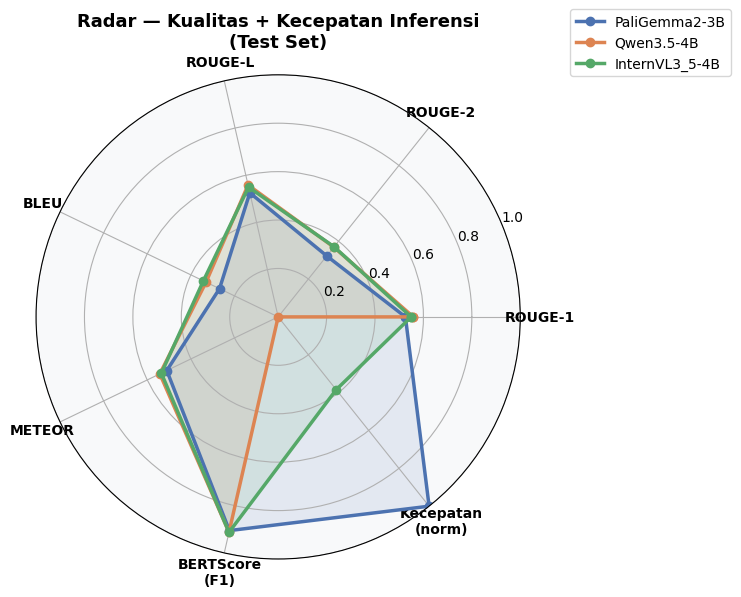

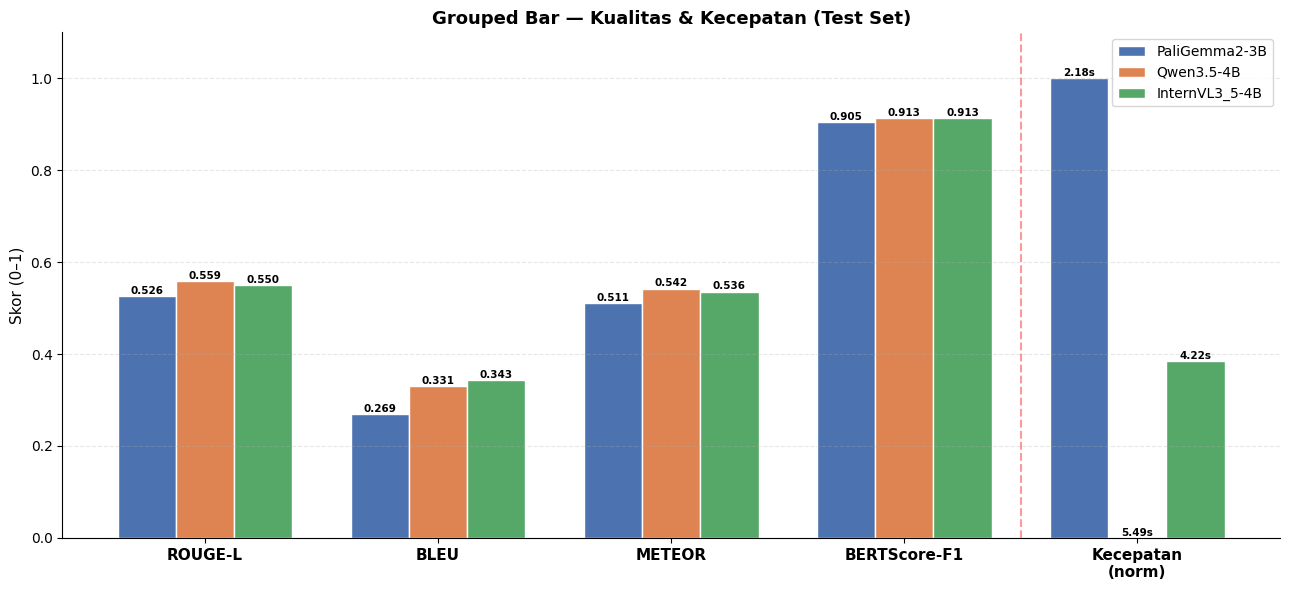

/tmp/ipykernel_23/1137810889.py:123: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1137810889.py:124: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/grafik_tradeoff.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


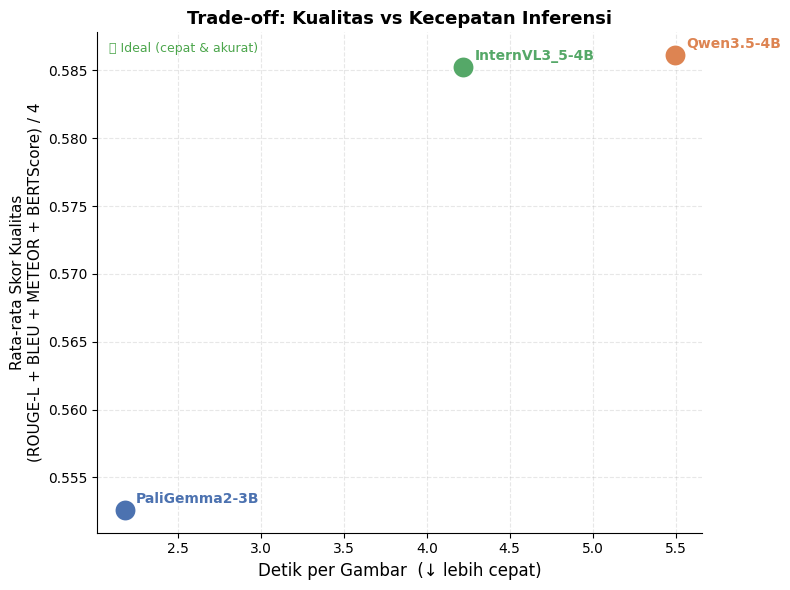


💾 Semua grafik tersimpan di /kaggle/working/


In [16]:
# ============================================================
# CELL 13: Semua Grafik
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/komparasi_model.csv")

WARNA_MODEL = {
    "PaliGemma2-3B": "#4C72B0",
    "Qwen3.5-4B":    "#DD8452", 
    "InternVL3_5-4B": "#55A868", 
}

model_list = df["Model"].tolist()
warna      = [WARNA_MODEL.get(m, "#999") for m in model_list]

df["Kecepatan (norm)"] = 1 - (
    (df["Detik/Gambar"] - df["Detik/Gambar"].min()) /
    (df["Detik/Gambar"].max() - df["Detik/Gambar"].min() + 1e-9)
)
df["Rata2_Kualitas"] = df[["ROUGE-L","BLEU","METEOR","BERTScore-F1"]].mean(axis=1)

# ── 1. Bar Chart Lengkap ────────────────────────────────────
metrik_plot = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU","METEOR","BERTScore-F1","Kecepatan (norm)"]
label_plot  = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU","METEOR","BERTScore\n(F1)","Kecepatan\n(norm,↑cepat)"]

fig, axes = plt.subplots(1, len(metrik_plot), figsize=(24, 5))
fig.suptitle("Komparasi Lengkap Metrik Evaluasi — Test Set",
             fontsize=14, fontweight='bold', y=1.03)
for ax, metrik, label in zip(axes, metrik_plot, label_plot):
    nilai = df[metrik].tolist()
    bars  = ax.bar(model_list, nilai, color=warna, edgecolor='white', width=0.55)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylim(0, min(1.15, max(nilai)*1.35))
    ax.tick_params(axis='x', rotation=20, labelsize=7)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top','right']].set_visible(False)
    if metrik == "Kecepatan (norm)":
        ax.set_facecolor('#FFF8F0')
    for bar, v, m in zip(bars, nilai, model_list):
        teks = f"{df.loc[df['Model']==m,'Detik/Gambar'].values[0]:.2f}s" \
               if metrik == "Kecepatan (norm)" else f"{v:.3f}"
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                teks, ha='center', fontsize=7.5, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/grafik_bar_lengkap.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Radar Chart ─────────────────────────────────────────
metrik_radar = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU","METEOR","BERTScore-F1","Kecepatan (norm)"]
label_radar  = ["ROUGE-1","ROUGE-2","ROUGE-L","BLEU","METEOR","BERTScore\n(F1)","Kecepatan\n(norm)"]
N      = len(metrik_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
ax.set_facecolor('#F8F9FA')
for _, row in df.iterrows():
    nilai = [row[m] for m in metrik_radar] + [row[metrik_radar[0]]]
    c = WARNA_MODEL.get(row["Model"], "#999")
    ax.plot(angles, nilai, 'o-', lw=2.5, color=c, label=row["Model"])
    ax.fill(angles, nilai, alpha=0.12, color=c)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(label_radar, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title("Radar — Kualitas + Kecepatan Inferensi\n(Test Set)",
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/grafik_radar.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Grouped Bar ─────────────────────────────────────────
metrik_grouped = ["ROUGE-L","BLEU","METEOR","BERTScore-F1","Kecepatan (norm)"]
label_grouped  = ["ROUGE-L","BLEU","METEOR","BERTScore-F1","Kecepatan\n(norm)"]
x      = np.arange(len(metrik_grouped))
lebar  = 0.25
offset = np.linspace(-(lebar*(len(model_list)-1)/2),
                      (lebar*(len(model_list)-1)/2), len(model_list))

fig, ax = plt.subplots(figsize=(13, 6))
for model, off in zip(model_list, offset):
    nilai = [df.loc[df["Model"]==model, m].values[0] for m in metrik_grouped]
    bars  = ax.bar(x+off, nilai, lebar,
                   label=model, color=WARNA_MODEL.get(model,"#999"),
                   edgecolor='white')
    for bar, v, met in zip(bars, nilai, metrik_grouped):
        teks = f"{df.loc[df['Model']==model,'Detik/Gambar'].values[0]:.2f}s" \
               if met == "Kecepatan (norm)" else f"{v:.3f}"
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                teks, ha='center', fontsize=7.5, fontweight='bold')
ax.axvline(x=3.5, color='red', linestyle='--', alpha=0.4, lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels(label_grouped, fontsize=11, fontweight='bold')
ax.set_ylabel("Skor (0–1)", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Grouped Bar — Kualitas & Kecepatan (Test Set)", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/grafik_grouped.png", dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Scatter Trade-off ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in df.iterrows():
    c = WARNA_MODEL.get(row["Model"], "#999")
    ax.scatter(row["Detik/Gambar"], row["Rata2_Kualitas"],
               s=250, color=c, zorder=5, edgecolors='white', lw=1.5)
    ax.annotate(row["Model"], xy=(row["Detik/Gambar"], row["Rata2_Kualitas"]),
                xytext=(8, 5), textcoords='offset points',
                fontsize=10, fontweight='bold', color=c)
ax.set_xlabel("Detik per Gambar  (↓ lebih cepat)", fontsize=12)
ax.set_ylabel("Rata-rata Skor Kualitas\n(ROUGE-L + BLEU + METEOR + BERTScore) / 4", fontsize=11)
ax.set_title("Trade-off: Kualitas vs Kecepatan Inferensi", fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.spines[['top','right']].set_visible(False)
ax.text(0.02, 0.98, "🏆 Ideal (cepat & akurat)", transform=ax.transAxes,
        fontsize=9, va='top', color='green', alpha=0.7)
plt.tight_layout()
plt.savefig("/kaggle/working/grafik_tradeoff.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Semua grafik tersimpan di /kaggle/working/")

In [17]:
# ============================================================
# CELL 14: Ranking Akhir
# ============================================================
df_rank = df.copy()
for col in ["ROUGE-L","BLEU","METEOR","BERTScore-F1"]:
    df_rank[f"Rank_{col}"] = df_rank[col].rank(ascending=False).astype(int)
df_rank["Rank_Kecepatan"] = df_rank["Detik/Gambar"].rank(ascending=True).astype(int)
df_rank["Rank_Akhir"] = df_rank[["Rank_ROUGE-L","Rank_BLEU","Rank_METEOR",
                                   "Rank_BERTScore-F1","Rank_Kecepatan"]].mean(axis=1).round(2)

print("\n" + "="*75)
print("🏆 RANKING AKHIR (lebih kecil = lebih unggul)")
print("="*75)
print(df_rank[["Model","ROUGE-L","BLEU","METEOR","BERTScore-F1",
               "Detik/Gambar","Rank_Akhir"]]
      .sort_values("Rank_Akhir").to_string(index=False))


🏆 RANKING AKHIR (lebih kecil = lebih unggul)
         Model  ROUGE-L   BLEU  METEOR  BERTScore-F1  Detik/Gambar  Rank_Akhir
    Qwen3.5-4B   0.5588 0.3307  0.5424        0.9126        5.4945         1.6
InternVL3_5-4B   0.5499 0.3429  0.5356        0.9126        4.2194         1.6
 PaliGemma2-3B   0.5257 0.2688  0.5106        0.9053        2.1786         2.6
